In [2]:
import pandas as pd
import sqlite3

df = pd.read_csv('student_sleep_mental_health_2026.csv')
print(df)


      student_id  age      gender education_level  avg_sleep_hours  \
0              1   21  Non-binary     High School              8.0   
1              2   19      Female   Undergraduate              7.3   
2              3   19        Male   Undergraduate              6.1   
3              4   16        Male     High School              6.2   
4              5   20        Male        Graduate              5.6   
...          ...  ...         ...             ...              ...   
2995        2996   23  Non-binary     High School              6.4   
2996        2997   23        Male   Undergraduate              6.9   
2997        2998   18        Male        Graduate              6.9   
2998        2999   22        Male   Undergraduate              7.0   
2999        3000   18      Female   Undergraduate              6.9   

      screen_time_hours  social_media_hours  study_hours_per_day  \
0                   4.9                 3.7                  5.0   
1                   7.7

# INTRODUCTION

This data is about the mental health and sleep schdule of students
based i theur screen time stress llevel caffine consuption and average sleep hours 

In [3]:
print(df.shape)

(3000, 15)


In [4]:
# This data has about 3000 rows and 15 colomnns 

In [5]:
# in this data the stress of students is shows as level and same with the anxiety score 

there must be a survey where they asked student if they uses a sleep app or not and if they feel  burnout or not 

In [7]:
# First we will check the null values in the data and remove them if there are any 

print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   object 
 3   education_level          3000 non-null   object 
 4   avg_sleep_hours          3000 non-null   float64
 5   screen_time_hours        3000 non-null   float64
 6   social_media_hours       3000 non-null   float64
 7   study_hours_per_day      3000 non-null   float64
 8   exercise_hours_per_week  3000 non-null   float64
 9   caffeine_drinks_per_day  3000 non-null   int64  
 10  stress_level             3000 non-null   int64  
 11  anxiety_score            3000 non-null   int64  
 12  gpa                      3000 non-null   float64
 13  uses_sleep_app           3000 non-null   bool   
 14  feels_burned_out        

By seeing this we can confirm that they have no nulll values and have their own data types it seems perfect 

In [9]:
# NOW WE Will check the statatics by using describe function

In [11]:
print(df.describe())

        student_id          age  avg_sleep_hours  screen_time_hours  \
count  3000.000000  3000.000000      3000.000000        3000.000000   
mean   1500.500000    19.445000         7.414067           6.494667   
std     866.169729     2.924921         0.971279           2.165014   
min       1.000000    14.000000         4.400000           1.000000   
25%     750.750000    17.000000         6.800000           5.000000   
50%    1500.500000    19.000000         7.400000           6.500000   
75%    2250.250000    21.000000         8.100000           8.000000   
max    3000.000000    29.000000        10.900000          13.600000   

       social_media_hours  study_hours_per_day  exercise_hours_per_week  \
count         3000.000000          3000.000000              3000.000000   
mean             3.575033             3.235200                 3.541900   
std              1.563631             1.405491                 2.336889   
min              0.000000             0.000000              

We can seee that there is almost double of mean to max diffrence in everyone except the caffine consuption and exercise and study hours social media intercation 

# SQL data extraction

In [13]:
# Now we will get the information from the sql

In [35]:
conn = sqlite3.connect('student.db')
df.to_sql('student_data' , conn , index = False , if_exists = 'replace')


query  = 'SELECT ("avg_sleep_hours") as poor_sleep FROM student_data WHERE poor_sleep < 6'
print('NUMBER OF STUDENTS HAVING POOR SLEEP OF LESS THAN 6 HOURS IN THE DATA ARE -',len(pd.read_sql_query(query,conn)))

print('--'*90)

query2  = 'SELECT "age" , "screen_time_hours" as avg_screen_time FROM student_data GROUP BY age ORDER BY avg_screen_time desc '
print('the average screen time with their ages : \n ',pd.read_sql_query(query2,conn))

print('--'*90)

query3 = 'SELECT "stress_level" , AVG("exercise_hours_per_week") as average_exc FROM student_data GROUP BY stress_level ORDER BY average_exc DESC'
print('the stress level along with their average excercise hours \n :',pd.read_sql_query(query3,conn))

print('--'*90)

query4 = 'SELECT "stress_level" , AVG("social_media_hours") as average_screen FROM student_data GROUP BY stress_level ORDER BY average_screen DESC'
print('the stress level along with their average screen hours \n :',pd.read_sql_query(query4,conn))

print('--'*90)

query5 = 'SELECT "stress_level" , AVG("gpa") as average_gpa FROM student_data GROUP BY stress_level ORDER BY average_gpa DESC'
print('the stress level along with their average gpa \n :',pd.read_sql_query(query5,conn))

print('--'*90)

query6 = 'SELECT "stress_level" , AVG("caffeine_drinks_per_day") as average_caffe FROM student_data GROUP BY stress_level ORDER BY stress_level DESC'
print('the stress level along with their average caffeine_drinks_per_day \n :',pd.read_sql_query(query6,conn))

NUMBER OF STUDENTS HAVING POOR SLEEP OF LESS THAN 6 HOURS IN THE DATA ARE - 212
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
the average screen time with their ages : 
      age  avg_screen_time
0    20             12.5
1    14              7.8
2    19              7.7
3    16              7.4
4    17              7.0
5    28              6.3
6    22              5.9
7    15              5.8
8    29              5.2
9    21              4.9
10   27              4.6
11   26              4.6
12   23              4.4
13   24              3.8
14   25              3.4
15   18              3.3
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
the stress level along with their average excercise hours 
 :    stress_level  average_e

# IMPORTANT INFORMATION

 SO THIS ANALYSIS CLEAR THESE THINGS - 
* THERE ARE 212 NUMBER OF STTUDENTS WITH THE SLEEP HOUR LESS THAN 6 HOURS OUT OF 3K WHICH SHOW ITS NOT THAT BAD
* SCREEN time of the students with age of 20 and 14 are highest 20have 12 hours of screen time as average and 14 have7 hours of screen time as average
* This data shows doing excercise actually help students to release their stress which shows they have negative correlation
* the stress level according to screen time it shows that the more screen time = more stress    imp------------
* it shows the more their gpa is = less their screen time is which shows their negative relaion
* it shows that the stress level according to their caffine and it shows that student with high caffine have less stress


# PANDAS DATA EXTRACTION

In [36]:
# NOW WE WILL USE PANDAS

In [93]:
genders = df['gender'].value_counts()

education_lvl = df['education_level'].value_counts()

uses_app = df['uses_sleep_app'].value_counts()

burnout = df['feels_burned_out'].value_counts()

app_sleep = df.groupby('uses_sleep_app')['avg_sleep_hours'].agg(['mean','min','max'])

educ_stress = df.groupby('education_level')['stress_level'].agg(['mean','min','max'])

over_exc = df['exercise_hours_per_week'].where(df['exercise_hours_per_week'] > 5)

oxer_exc =(over_exc).dropna()

print('student doing excercide for more than 5 hours : ',len((over_exc).dropna()))

print('--'*90)

print(educ_stress)

print('--'*90)

print(app_sleep)

print('--'*90)

print(burnout)

print('--'*90)

print(uses_app)

print('--'*90)

print(education_lvl)

print('--'*90)

print(genders)

student doing excercide for more than 5 hours :  773
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                     mean  min  max
education_level                    
Graduate         7.230233    3   10
High School      7.100112    2   10
Undergraduate    7.274836    1   10
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                    mean  min   max
uses_sleep_app                     
False           7.411765  4.4  10.9
True            7.418482  4.6  10.4
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
feels_burned_out
True     2039
False     961
Name: count, dtype: int64
---------

# extra detail

* There are 2039 students who feels burnout and 961 dont
* there are 1972 peoples who uses the sleep apps and 1028 dont but this app is barely helping them to improve their sleep
* there re 1681 ungraduated and 889 high school students and 430 graduated ungraduated have most stress level of them 
* their are 1410 females , 1406 males ,110 binary and 74 do not prefer to say in the data 


# PLOTTING ON GRAPH

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

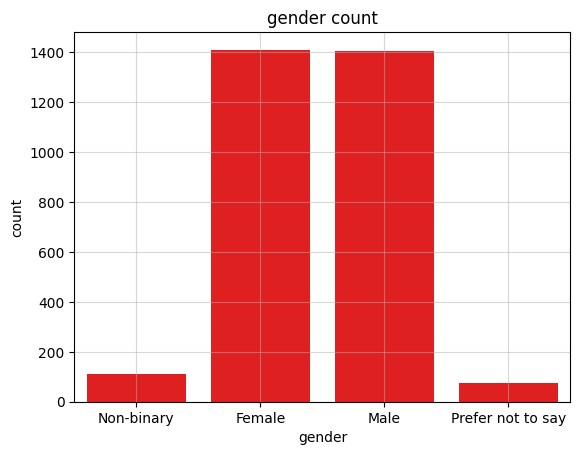

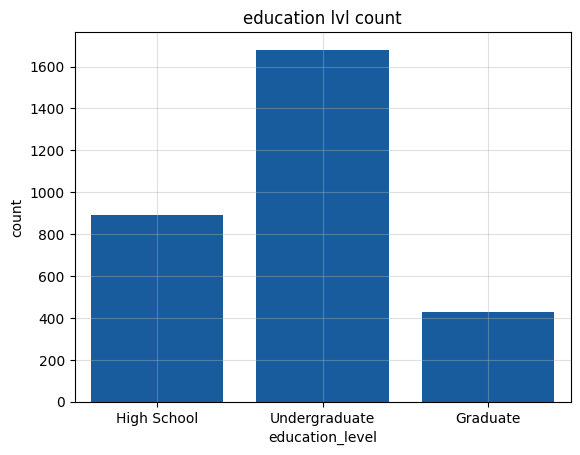

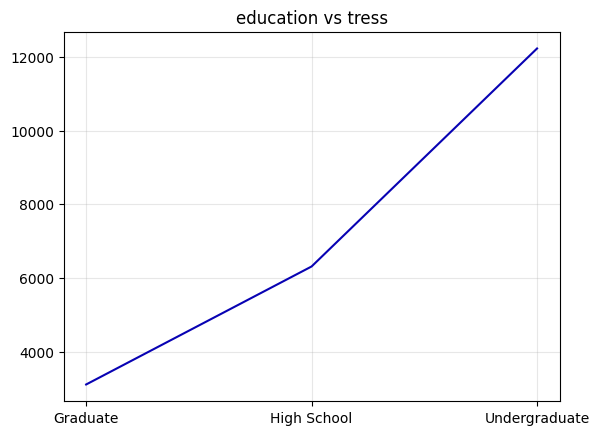

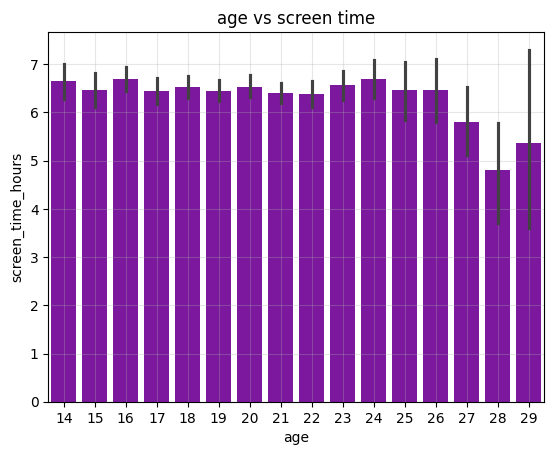

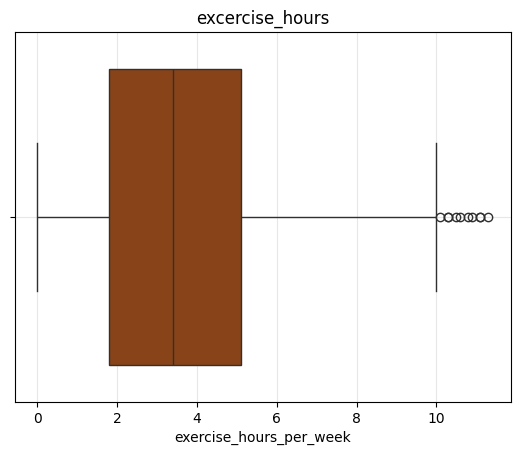

In [100]:
sns.countplot(data = df , x = 'gender',color = 'red')
plt.title('gender count')
plt.grid(True , alpha = 0.5)
plt.show()

sns.countplot(data = df , x = 'education_level' , color = '#025db3')
plt.grid(True , alpha = 0.4)
plt.title('education lvl count')
plt.show()

education_stress = df.groupby('education_level')['stress_level'].sum()
plt.plot(education_stress.index , education_stress.values , color = '#0802b3')
plt.grid(True , alpha = 0.3)
plt.title('education vs tress')
plt.show()

sns.barplot(data = df , x = 'age' , y = 'screen_time_hours' , color = '#8602b3')
plt.title('age vs screen time')
plt.grid(True , alpha = 0.3)
plt.show()

sns.boxplot(data = df , x = 'exercise_hours_per_week', color = '#9c3f05')
plt.title('excercise_hours')
plt.grid(True , alpha = 0.3)
plt.show()


# CORRELATION GRAPH

In [105]:
print(df.corr(numeric_only = True))

                         student_id       age  avg_sleep_hours  \
student_id                 1.000000  0.006229        -0.021853   
age                        0.006229  1.000000        -0.008671   
avg_sleep_hours           -0.021853 -0.008671         1.000000   
screen_time_hours          0.025978 -0.024121        -0.587266   
social_media_hours         0.032283 -0.038311        -0.453081   
study_hours_per_day       -0.047137 -0.008427         0.010074   
exercise_hours_per_week   -0.030074  0.006877        -0.002421   
caffeine_drinks_per_day   -0.016746 -0.004718         0.001162   
stress_level               0.030914  0.015134        -0.495939   
anxiety_score              0.033283 -0.018625        -0.360881   
gpa                       -0.020479  0.004684         0.522262   
uses_sleep_app            -0.021833  0.023666         0.003283   
feels_burned_out           0.013115  0.007975        -0.386412   

                         screen_time_hours  social_media_hours  \
student_i

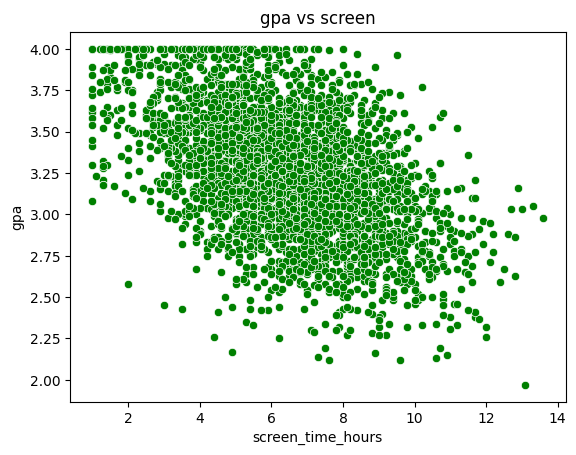

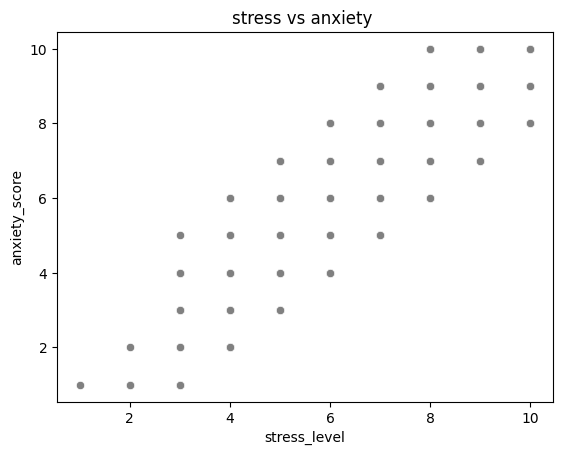

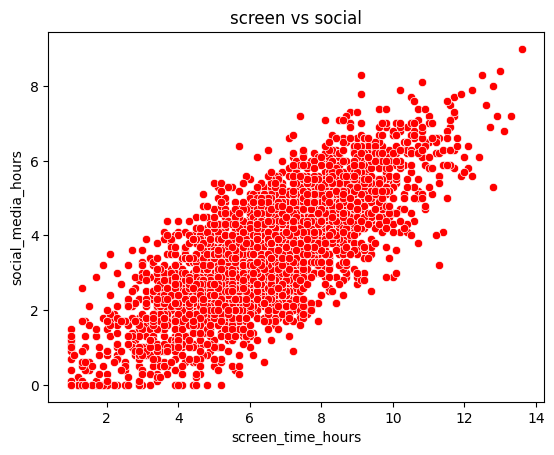

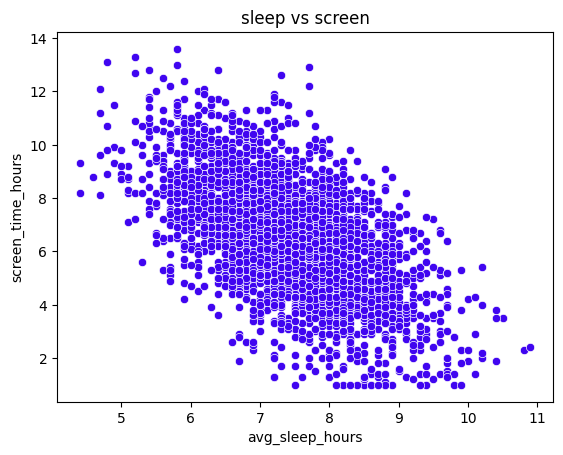

In [110]:
sns.scatterplot(data = df , x = 'screen_time_hours' , y = 'gpa' , color = 'green')
plt.title('gpa vs screen')
plt.show()

sns.scatterplot(data = df , x = 'stress_level' , y  = 'anxiety_score' , color = 'grey')
plt.title('stress vs anxiety ')
plt.show()

sns.scatterplot(data = df , x = 'screen_time_hours' , y = 'social_media_hours' , color = 'red')
plt.title('screen vs social')
plt.show()

sns.scatterplot(data = df , x = 'avg_sleep_hours' , y = 'screen_time_hours' , color = '#4005f0')
plt.title('sleep vs screen')
plt.show()

# FINAL VERDICT

This data helps us understand that many students are facing difficulties in their studies, and
their sleep schedules are not healthy. Due to academic pressure, students experience
increased stress. In addition, excessive screen time reduces sleep, which can lead to
problems such as anxiety, stress, and increased caffeine consumption. These habits can
negatively affect both their health and academic performance.
The analysis also shows that regular exercise may help reduce stress, although not every
student follows this habit. According to the data, students around the age of 20 have the
highest average screen time, and undergraduate students show the highest stress levels.
The correlation analysis provides strong evidence that higher screen time is associated with
several negative outcomes, including reduced sleep, increased stress, and lower GPA.
Although screen time is not the only factor affecting students' well-being, reducing
unnecessary screen time can help improve many of these issues.
Recommendations
* Keep daily screen time below 6–7 hours whenever possible.
* Exercise regularly to reduce stress and improve mental health.
* Maintain a healthy and consistent sleep schedule.
* Balance study time with proper rest and physical activity.